In [95]:
import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen
from snntorch import surrogate
from snntorch import functional as SF

import torch
import torch.nn as nn
import torch.nn.functional as nf
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import itertools

In [96]:
batch_size = 128
data_path='/tmp/data/mnist'

dtype = torch.float

In [97]:
transform = transforms.Compose([
            transforms.Resize((28, 28)),
            transforms.Grayscale(),
            transforms.ToTensor(),
            transforms.Normalize((0,), (1,))])

mnist_train = datasets.MNIST(data_path, train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(data_path, train=False, download=True, transform=transform)

In [98]:
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=True, drop_last=True)

In [99]:
data, targets = next(iter(train_loader))

In [100]:
data1, targets1 = next(iter(test_loader))

torch.Size([128, 1, 28, 28])
tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.

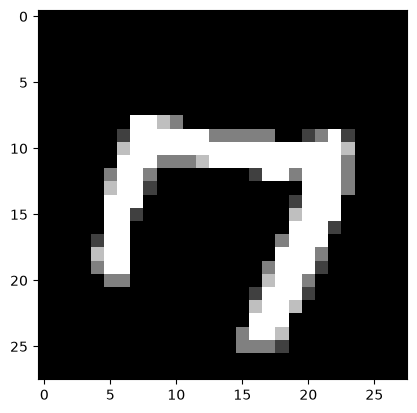

In [101]:
print(data.shape)
print(data[0])
print(data[0]*255)
plt.imshow(data[0].squeeze(),cmap='gray')
plt.show()

In [102]:
# Network Architecture
num_inputs = 28*28
num_hidden = 1000
num_outputs = 10

# Temporal Dynamics
num_steps = 25
beta = 0.95
spike_grad = surrogate.fast_sigmoid(slope=25)

In [103]:
# Define Network
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Initialize layers
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta,spike_grad=spike_grad)
        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=beta,spike_grad=spike_grad)

    def forward(self, x):

        # Initialize hidden states at t=0
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        # Record the final layer
        spk_rec = []
        mem_rec = []

        for step in range(num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk_rec.append(spk2)
            mem_rec.append(mem2)

        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)

net = Net()

In [104]:
loss = SF.ce_rate_loss()

In [105]:
optimizer = torch.optim.Adam(net.parameters(), lr=5e-4, betas=(0.9, 0.999))

In [106]:
spk_rec1, mem_rec = net(data.view(batch_size,-1))
print(spk_rec1.shape)

torch.Size([25, 128, 10])


In [107]:
loss_val = loss(spk_rec1, targets)
acc = SF.accuracy_rate(spk_rec1, targets)

In [108]:
print(loss_val.item())
print(acc*100)

2.3065476417541504
10.9375


In [109]:
def batch_accuracy(t_l, net, num_steps):
  with torch.no_grad():
    total = 0
    acc = 0
    net.eval()

    train_loader = iter(t_l)

    for data, targets in train_loader:
        spk_rec, _ = net(data.view(batch_size, -1))
        acc += SF.accuracy_rate(spk_rec, targets) * spk_rec.size(1)
        total += spk_rec.size(1)

  return acc/total

In [110]:
test_acc = batch_accuracy(test_loader, net, num_steps)

In [111]:
print(test_acc*100)

10.06610576923077


orginal no  9
predicted no  1


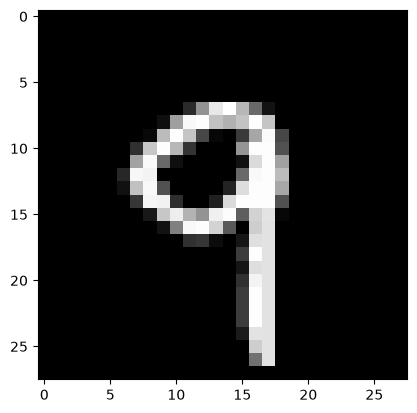

tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 

In [112]:
n = 13
s,m = net(data1[n].view(1, -1))
s_sum = s.sum(dim = 0)
pc = s_sum.argmax(dim = 1)
print("orginal no ",targets1[n].item())
print("predicted no ",pc.item())
plt.imshow(data1[n].squeeze(),cmap='gray')
plt.show()
print(s)

In [113]:
num_epochs = 5
loss_hist = []
test_acc_hist = []
counter = 0

# Outer training loop
for epoch in range(num_epochs):
    for data, targets in iter(train_loader):
        spk_rec, _ = net(data.view(batch_size, -1))
        loss_val = loss(spk_rec, targets)
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()
        loss_hist.append(loss_val.item())
        if counter % 50 == 0:
            with torch.no_grad():
                net.eval()
                test_acc = batch_accuracy(test_loader, net, num_steps)
                print(f"Iteration {counter}, Test Acc: {test_acc * 100:.2f}%\n")
                test_acc_hist.append(test_acc.item())
        counter += 1

Iteration 0, Test Acc: 18.98%

Iteration 50, Test Acc: 88.36%

Iteration 100, Test Acc: 91.21%

Iteration 150, Test Acc: 92.15%

Iteration 200, Test Acc: 92.36%

Iteration 250, Test Acc: 93.40%

Iteration 300, Test Acc: 93.77%

Iteration 350, Test Acc: 94.04%

Iteration 400, Test Acc: 94.53%

Iteration 450, Test Acc: 94.80%

Iteration 500, Test Acc: 95.13%

Iteration 550, Test Acc: 94.84%

Iteration 600, Test Acc: 95.49%

Iteration 650, Test Acc: 95.49%

Iteration 700, Test Acc: 95.49%

Iteration 750, Test Acc: 95.83%

Iteration 800, Test Acc: 95.92%

Iteration 850, Test Acc: 96.24%

Iteration 900, Test Acc: 96.22%

Iteration 950, Test Acc: 96.43%

Iteration 1000, Test Acc: 96.56%

Iteration 1050, Test Acc: 96.56%

Iteration 1100, Test Acc: 96.66%

Iteration 1150, Test Acc: 96.71%

Iteration 1200, Test Acc: 96.63%

Iteration 1250, Test Acc: 96.77%

Iteration 1300, Test Acc: 96.86%

Iteration 1350, Test Acc: 97.00%

Iteration 1400, Test Acc: 96.88%

Iteration 1450, Test Acc: 96.99%

Ite

orginal no  3
predicted no  3


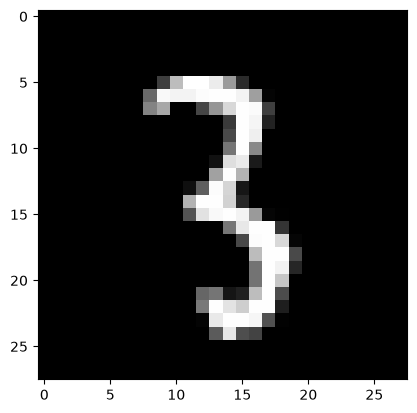

tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 

In [88]:
n = 13
s,m = net(data1[n].view(1, -1))
s_sum = s.sum(dim = 0)
pc = s_sum.argmax(dim = 1)
print("orginal no ",targets1[n].item())
print("predicted no ",pc.item())
plt.imshow(data1[n].squeeze(),cmap='gray')
plt.show()
print(s)


In [89]:
wrong_imgs = []
wrong_preds = []
wrong_labels = []

net.eval()

with torch.no_grad():

    for data, targets in test_loader:

        spk_rec, mem_rec = net(data.view(data.size(0), -1))

        # Sum spikes over time
        spk_sum = spk_rec.sum(dim=0)

        # Predicted class
        preds = spk_sum.argmax(dim=1)

        # Find wrong predictions
        wrong = preds != targets

        wrong_imgs.extend(data[wrong])
        wrong_preds.extend(preds[wrong])
        wrong_labels.extend(targets[wrong])

print("Total wrong predictions:", len(wrong_imgs))

Total wrong predictions: 512


Actual : 2
Predicted : 8


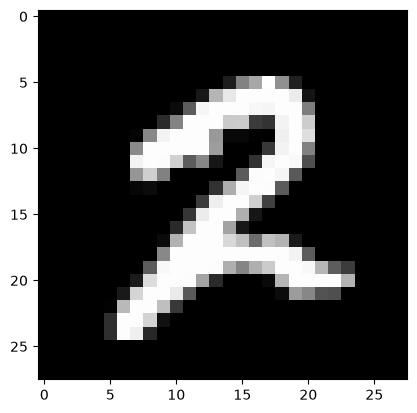

In [94]:
n = 317
plt.imshow(wrong_imgs[n].squeeze(), cmap='gray')

print("Actual :", wrong_labels[n].item())
print("Predicted :", wrong_preds[n].item())

plt.show()